# Exploratory Data Analysis (EDA)

This notebook explores the UCI Disease dataset to understand the structure, distributions, and potential issues prior to modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/heart_disease_uci.csv", index_col='id')


In [2]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 920 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 115.0+ KB


In [4]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


Initial inspection shows that the dataset contains clinical observations from multiple data sources, with both numerical and categorical variables.

Serveral variables are stored as strings represeting clinical categories, while others are numerical measurements such as blood pressure and heart rate. 

In [5]:
df.shape

(920, 15)

In [6]:
df["dataset"].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

The dataset aggregates records from four different clinical sources: Cleveland, Hungary, Switzerland, and VA Long Beach.

Data completeness and quality appear to vary substantially across clinical sources, suggesting the need for careful subset selection before modeling.

In [7]:
df.groupby("dataset")["num"].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
Cleveland,304.0,0.934211,1.227684,0.0,0.0,0.0,2.0,4.0
Hungary,293.0,0.361775,0.481336,0.0,0.0,0.0,1.0,1.0
Switzerland,123.0,1.804878,1.013503,0.0,1.0,2.0,3.0,4.0
VA Long Beach,200.0,1.520000,1.219441,0.0,0.0,1.0,3.0,4.0


In [8]:
df.groupby("dataset")["chol"].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
Cleveland,304.0,246.315789,52.108280,126.0,211.00,240.5,275.00,564.0
Hungary,270.0,251.288889,67.393465,85.0,209.25,244.0,282.75,603.0
Switzerland,123.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
VA Long Beach,193.0,178.746114,114.035232,0.0,0.00,216.0,258.00,458.0


In [9]:
for name, group in df.groupby("dataset"):
    print(f"--- Dataset: {name} ---")
    print(group.isnull().sum())
    print("\n")

--- Dataset: Cleveland ---
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       1
ca          5
thal        3
num         0
dtype: int64


--- Dataset: Hungary ---
age           0
sex           0
dataset       0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalch        1
exang         1
oldpeak       0
slope       189
ca          290
thal        265
num           0
dtype: int64


--- Dataset: Switzerland ---
age           0
sex           0
dataset       0
cp            0
trestbps      2
chol          0
fbs          75
restecg       1
thalch        1
exang         1
oldpeak       6
slope        17
ca          118
thal         52
num           0
dtype: int64


--- Dataset: VA Long Beach ---
age           0
sex           0
dataset       0
cp            0
trestbps     56
chol          7
fbs           7
restecg       0
thalch       53
exang    

In [10]:
numerical_vars = ["age", "trestbps", "chol", "thalch", "oldpeak"]

for name, group in df.groupby('dataset'):
    print(f"--- Dataset: {name} ---")
    print((group[numerical_vars] == 0).sum())
    print("\n")

--- Dataset: Cleveland ---
age           0
trestbps      0
chol          0
thalch        0
oldpeak     100
dtype: int64


--- Dataset: Hungary ---
age           0
trestbps      0
chol          0
thalch        0
oldpeak     188
dtype: int64


--- Dataset: Switzerland ---
age           0
trestbps      0
chol        123
thalch        0
oldpeak      42
dtype: int64


--- Dataset: VA Long Beach ---
age          0
trestbps     1
chol        49
thalch       0
oldpeak     40
dtype: int64




Substantial differences are observed across data sources. In particular, the Cleveland subset exhibits more complete and clinically consistent measurements, while other subsets show extensive missingness in serum cholesterol.

This motivates using the Cleveland data as a baseline for subsequent modeling. 

In [11]:
cleveland = df[df["dataset"] == "Cleveland"].copy()

cleveland.shape

(304, 15)

In [12]:
cleveland["num"].value_counts().sort_index()

num
0    165
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [13]:
cleveland["num"].value_counts(normalize=True).sort_index()

num
0    0.542763
1    0.180921
2    0.118421
3    0.115132
4    0.042763
Name: proportion, dtype: float64

The outcome variable 'num' represents heart disease diagnosis levels, ranging from 0 (no disease) to 4 (severe disease).

For modeling purposes, this variable can be viewed as a binary indicator of disease presence versus absence in subsequent analysis.

In [14]:
cleveland[numerical_vars].describe()

,age,trestbps,chol,thalch,oldpeak
count,304.000000,304.000000,304.000000,304.000000,304.000000
mean,54.351974,131.684211,246.315789,149.723684,1.036184
std,9.150256,17.570949,52.108280,22.927263,1.160690
min,28.000000,94.000000,126.000000,71.000000,0.000000
25%,47.750000,120.000000,211.000000,133.750000,0.000000
50%,55.500000,130.000000,240.500000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


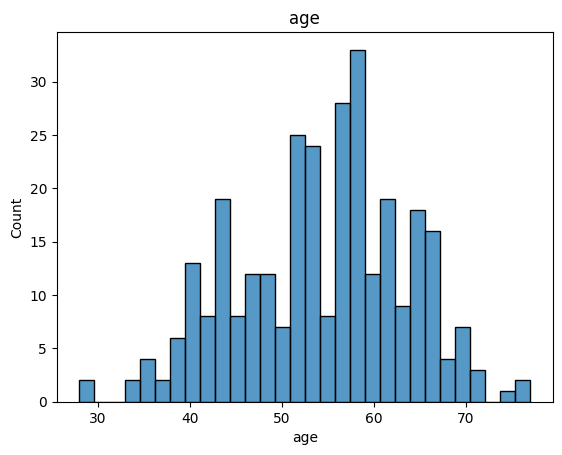

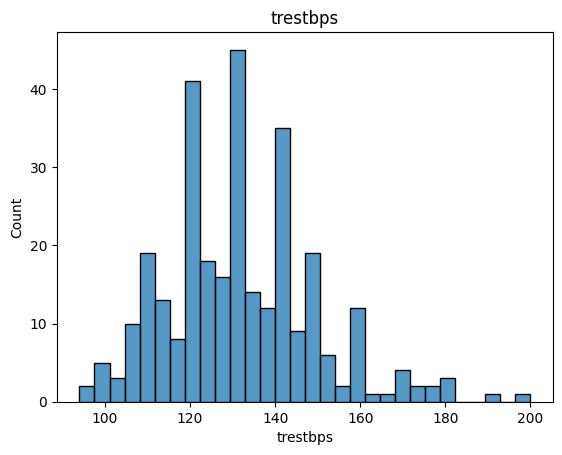

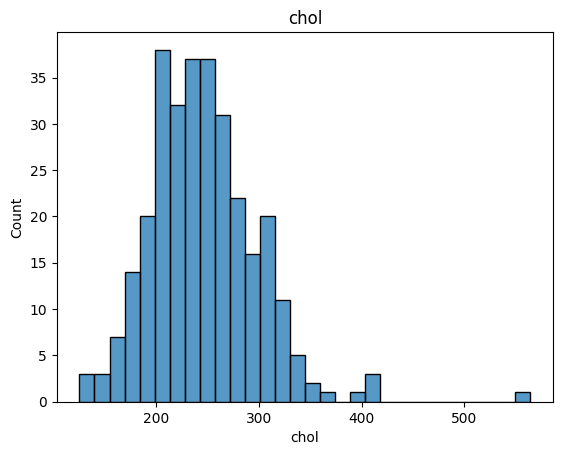

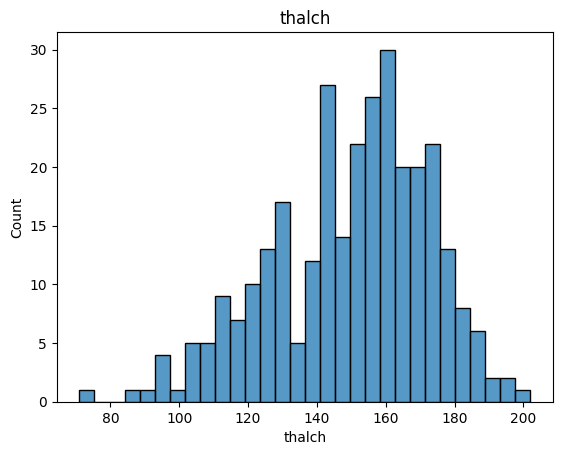

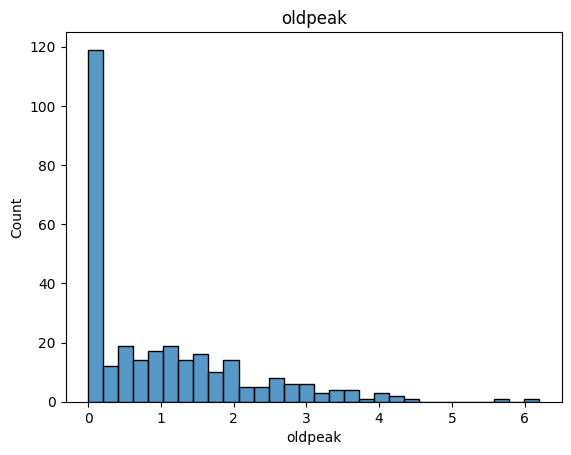

In [15]:
for col in numerical_vars:
    sns.histplot(cleveland[col],bins=30, kde=False)
    plt.title(col)
    plt.show()

Most numerical variables fall within clinically plausible ranges. However, some variables (e.g., cholesterol and oldpeak ect.) exhibit heavy right tails and extreme values.

Such distributional characteristics suggest that standardized scaling may be required for modeling, and interpretation should be cautious for extreme observations.

In [16]:
categorical_vars = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for col in categorical_vars:
    print(f"--- Categorical Variable: {col} ---")
    print(cleveland[col].value_counts())
    print("\n")

--- Categorical Variable: sex ---
sex
Male      207
Female     97
Name: count, dtype: int64


--- Categorical Variable: cp ---
cp
asymptomatic       144
non-anginal         86
atypical angina     51
typical angina      23
Name: count, dtype: int64


--- Categorical Variable: fbs ---
fbs
False    259
True      45
Name: count, dtype: int64


--- Categorical Variable: restecg ---
restecg
normal              151
lv hypertrophy      149
st-t abnormality      4
Name: count, dtype: int64


--- Categorical Variable: exang ---
exang
False    205
True      99
Name: count, dtype: int64


--- Categorical Variable: slope ---
slope
upsloping      142
flat           140
downsloping     21
Name: count, dtype: int64


--- Categorical Variable: thal ---
thal
normal               166
reversable defect    117
fixed defect          18
Name: count, dtype: int64




In [17]:
pd.crosstab(cleveland["cp"], df["num"] > 0, normalize="index")

num,False,True
cp,,
asymptomatic,0.270833,0.729167
atypical angina,0.823529,0.176471
non-anginal,0.790698,0.209302
typical angina,0.695652,0.304348


In [18]:
pd.crosstab(cleveland["exang"], df["num"] > 0, normalize="index")

num,False,True
exang,,
False,0.692683,0.307317
True,0.232323,0.767677


Categorical features such as chest pain type and exercise-induced anaina show strong associations with heart disease presence.

Notably, many high-risk patients fall into the asymptomatic chest pain category, reflecting clinically recognized diagonostic challenges.

### Summary of Exploratory Analysis

- The dataset consists primarily of numerical and categorical clinical measures.
- Outcome variable distributions reflect a high risk clinical population.
- Data quality varies significantly across sources.
- The Cleveland subset provides the most suitable basis for interpretable and reliable modeling.

These observations directly inform the modeling strategy adopted in the ext stage.